# Rec v1 — ML Pipeline Walkthrough
This notebook walks through the data loading, feature engineering, model training, and evaluation steps for the Learning-to-Rank recommendation model.

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import os

# Change working directory to project root since notebook is in notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Increase display limits for data exploration
pd.set_option('display.max_columns', None)

## 1. Load Data
We load the upstream candidate matches and the historical placement outcomes.

In [4]:
# Load Upstream Matches (Matching v1)
matches_df = pd.read_csv("data/matching_v1_output.csv")
print(f"Candidates: {len(matches_df)} rows")

# Load Training Signal (Outcomes)
outcomes_df = pd.read_csv("data/placement_outcomes.csv")
print(f"Outcomes: {len(outcomes_df)} rows")

display(matches_df.head(3))

Candidates: 1078 rows
Outcomes: 642 rows


,student_id,college_id,job_id,match_score,skill_overlap_count,skill_gap_count,years_exposure_avg,jd_seniority_level,verified_skill_count,ai_trust_score
0,student_A_0,college_A,job_7,0.949,6,2,2.5,2,7,0.892
1,student_A_0,college_A,job_1,0.616,4,5,3.4,5,7,0.701
2,student_A_0,college_A,job_47,0.914,7,1,1.2,5,8,0.848


## 2. Feature Engineering
Add derived signals like `skill_gap_ratio`, `seniority_match`, and `trust_weighted_score`.

In [5]:
df = matches_df.copy()

# Derived Features
df["skill_gap_ratio"] = df["skill_gap_count"] / (df["skill_overlap_count"] + 1e-5)
df["seniority_match"] = (abs(df["jd_seniority_level"] - df["years_exposure_avg"].round()) <= 1).astype(int)
df["trust_weighted_score"] = df["match_score"] * df["ai_trust_score"]

# College Level Baseline
college_avg = df.groupby("college_id")["match_score"].mean().reset_index().rename(columns={"match_score": "college_avg_match_score"})
df = df.merge(college_avg, on="college_id", how="left")

# Join Outcomes for supervised training
train_df = df.merge(outcomes_df, on=["student_id", "job_id"], how="inner")
print(f"Training set: {len(train_df)} pairs with known outcomes.")

Training set: 642 pairs with known outcomes.


## 3. Train/Test Split
Splitting by `student_id` prevents data leakage (we evaluate on unseen students).

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(train_df, groups=train_df["student_id"]))

X = train_df[[
    "match_score", "skill_overlap_count", "skill_gap_count",
    "years_exposure_avg", "jd_seniority_level", "verified_skill_count",
    "ai_trust_score", "skill_gap_ratio", "seniority_match", 
    "trust_weighted_score", "college_avg_match_score"
]]
y = train_df["outcome"]

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 445, Test size: 197


## 4. Train Gradient Boosting Ranker

In [7]:
model = GradientBoostingClassifier(
    n_estimators=80, max_depth=3, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=5, random_state=42,
)
model.fit(X_train, y_train)

print(f"Train Accuracy: {model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {model.score(X_test, y_test):.4f}")

Train Accuracy: 0.8787
Test Accuracy:  0.5685


## 5. Feature Importances

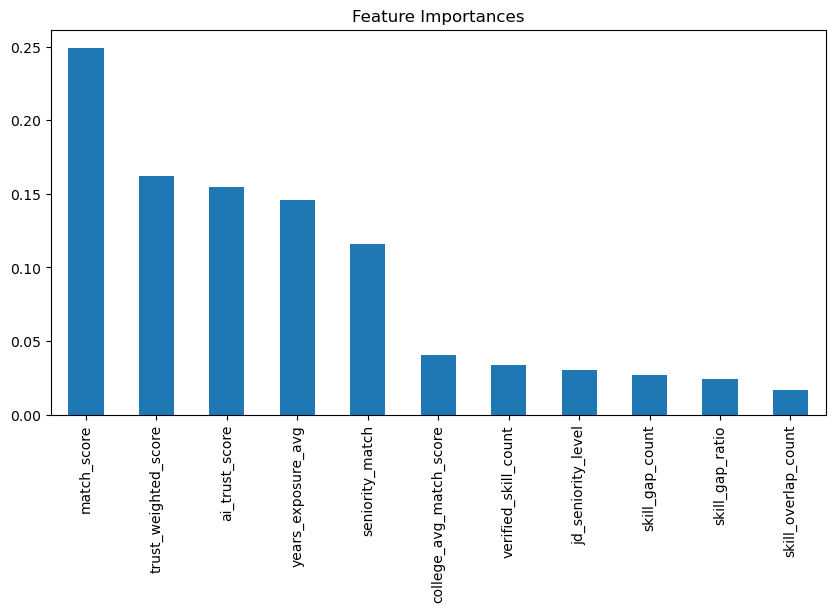

In [8]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 5), title="Feature Importances")
plt.show()

## 6. Ranking Prediction Example
Let's predict scores for a student in the test set and see how the model re-ranks jobs vs the raw match_score baseline.

In [9]:
test_student_id = train_df.iloc[test_idx]["student_id"].values[0]
student_cands = train_df[train_df["student_id"] == test_student_id].copy()

# Add Model Score
student_cands["model_score"] = model.predict_proba(student_cands[X.columns])[:, 1]

print(f"--- Student: {test_student_id} ---")
print("\n1. Baseline Ranking (Raw Match Score):")
display(student_cands[["job_id", "match_score", "outcome"]].sort_values("match_score", ascending=False))

print("\n2. Model Ranking (Gradient Boosting relevance):")
display(student_cands[["job_id", "model_score", "outcome"]].sort_values("model_score", ascending=False))

--- Student: student_A_0 ---

1. Baseline Ranking (Raw Match Score):


,job_id,match_score,outcome
0,job_7,0.949,1
7,job_40,0.932,1
1,job_47,0.914,1
4,job_5,0.799,1
3,job_8,0.672,1
6,job_48,0.601,0
5,job_2,0.591,1
2,job_17,0.559,1



2. Model Ranking (Gradient Boosting relevance):


,job_id,model_score,outcome
7,job_40,0.890634,1
1,job_47,0.762656,1
0,job_7,0.589677,1
4,job_5,0.462391,1
5,job_2,0.213089,1
2,job_17,0.204772,1
6,job_48,0.198862,0
3,job_8,0.140826,1
